In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape: (119390, 32)

Columns:
Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   ---

In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [7]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [8]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicates: 31994
Shape after removing duplicates: (87396, 32)


In [10]:
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')

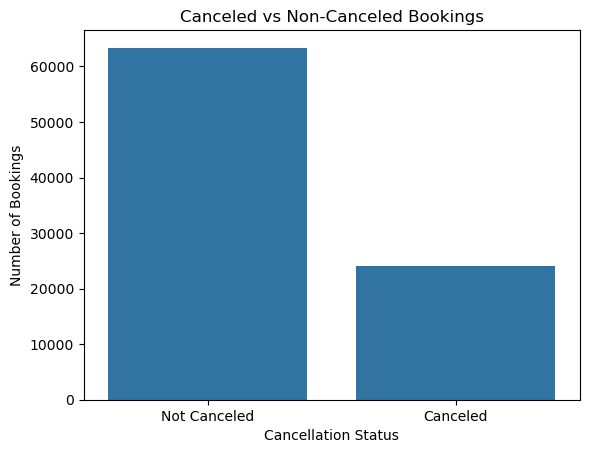

In [11]:
sns.countplot(data=df, x='is_canceled')
plt.title("Canceled vs Non-Canceled Bookings")
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")
plt.xticks([0, 1], ["Not Canceled", "Canceled"])
plt.show()

hotel
City Hotel      30.038557
Resort Hotel    23.480923
Name: is_canceled, dtype: float64


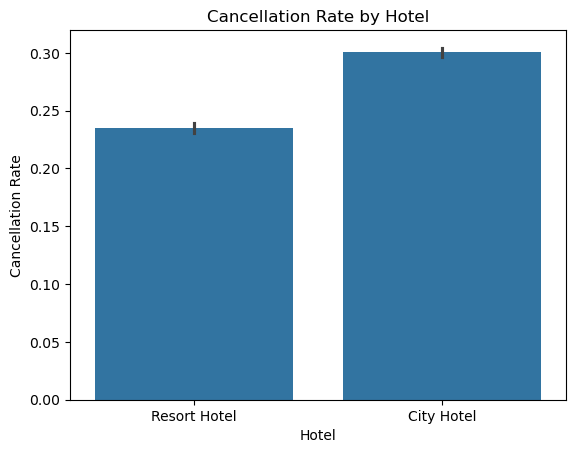

In [14]:
#Cancellation rate by hotel
cancellation_rate = df.groupby('hotel')['is_canceled'].mean() * 100
print(cancellation_rate)

sns.barplot(data=df, x='hotel', y='is_canceled')
plt.title("Cancellation Rate by Hotel")
plt.xlabel("Hotel")
plt.ylabel("Cancellation Rate")
plt.show()

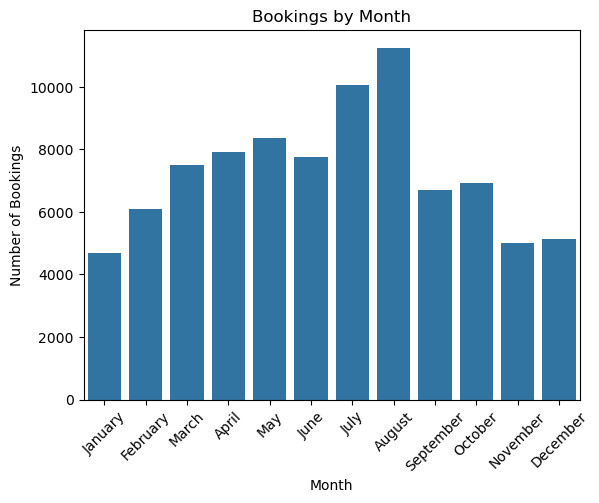

In [15]:
#Bookings by month
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]
monthly_bookings = df['arrival_date_month'].value_counts().reindex(month_order)
sns.barplot(x=monthly_bookings.index, y=monthly_bookings.values)
plt.title("Bookings by Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

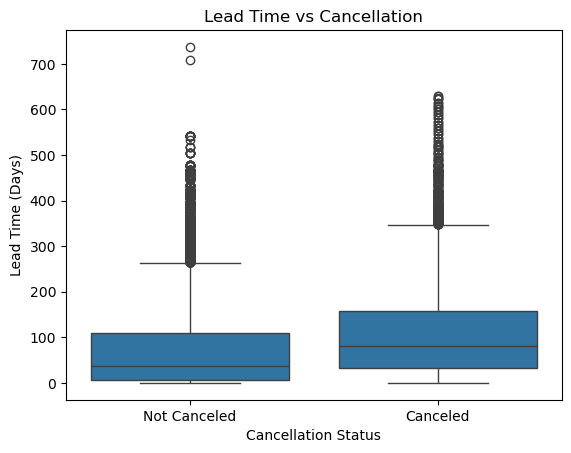

In [16]:
#Lead time vs cancellation
sns.boxplot(data=df, x='is_canceled', y='lead_time')
plt.title("Lead Time vs Cancellation")
plt.xlabel("Cancellation Status")
plt.ylabel("Lead Time (Days)")
plt.xticks([0, 1], ["Not Canceled", "Canceled"])
plt.show()

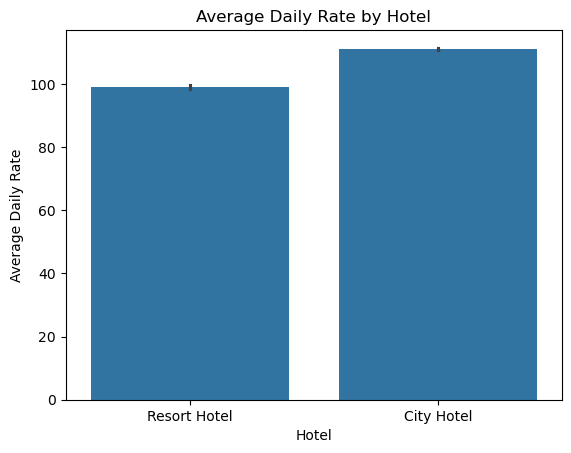

In [17]:
#Average daily rate by hotel
sns.barplot(data=df, x='hotel', y='adr')
plt.title("Average Daily Rate by Hotel")
plt.xlabel("Hotel")
plt.ylabel("Average Daily Rate")
plt.show()

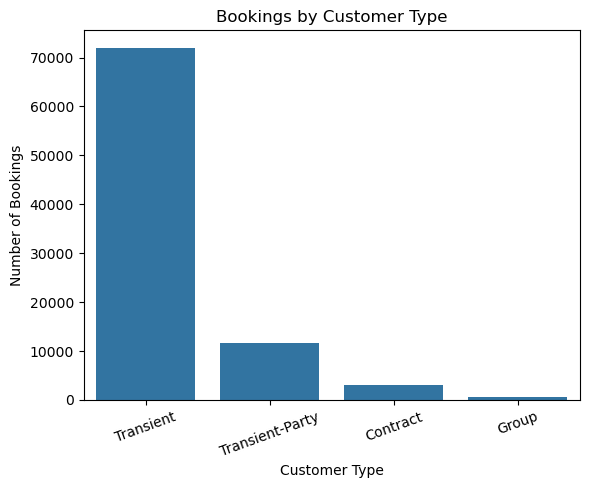

In [19]:
#Customer type
sns.countplot(
    data=df,
    x='customer_type',
    order=df['customer_type'].value_counts().index
)
plt.title("Bookings by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=20)
plt.show()

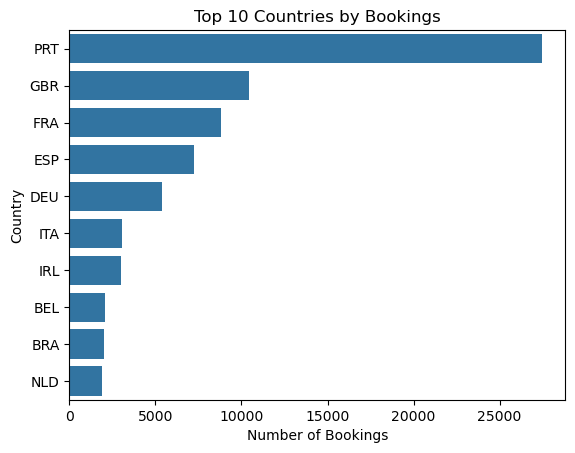

In [20]:
#Top 10 countries
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Country")
plt.show()

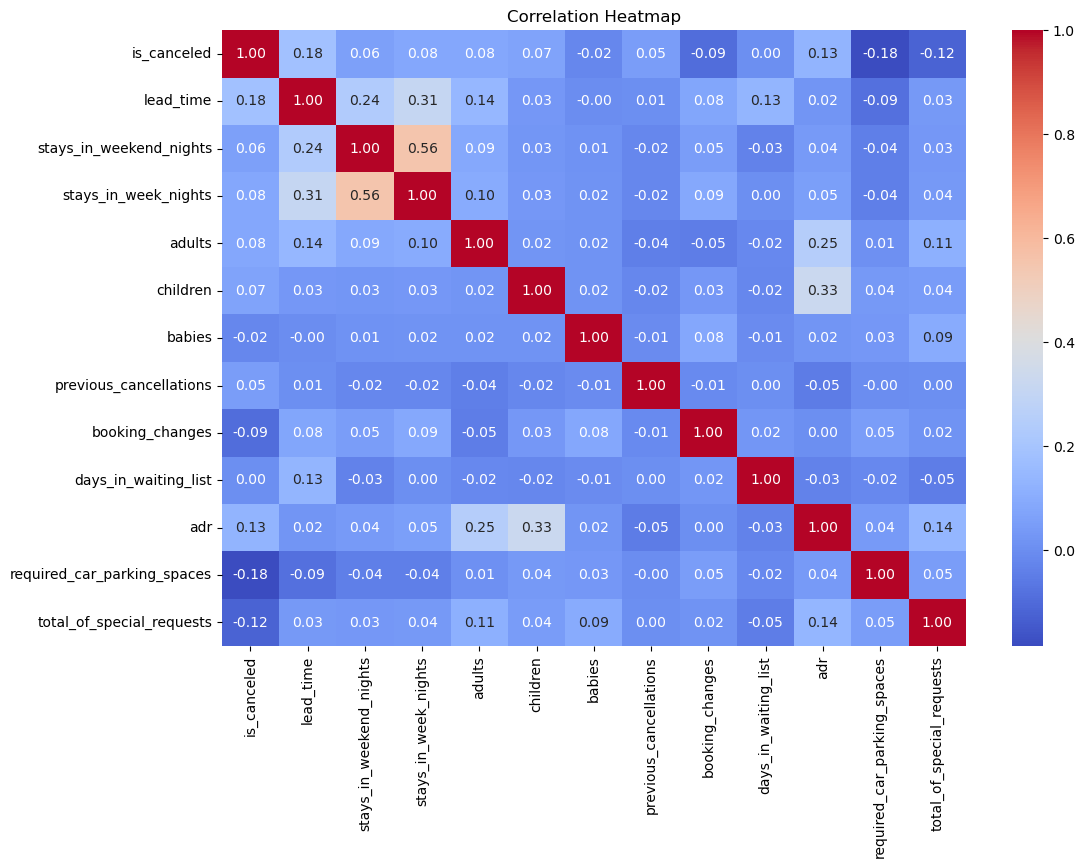

In [21]:
numeric_columns = [
    'is_canceled',
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests']
correlation = df[numeric_columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [22]:
print("Total Bookings:", len(df))
print("Cancellation Rate:",round(df['is_canceled'].mean() * 100, 2),"%")
print("Average Lead Time:",round(df['lead_time'].mean(), 2),"days")
print("Average ADR:",round(df['adr'].mean(), 2))

Total Bookings: 87396
Cancellation Rate: 27.49 %
Average Lead Time: 79.89 days
Average ADR: 106.34


In [24]:
#insi
#27.49% of bookings were canceled.
#City Hotel had more cancellations than Resort Hotel.
#August had the highest number of bookings.
#Canceled bookings had higher lead time.
#City Hotel had higher average ADR.
#Transient customers were the largest customer group.
#Portugal had the most bookings.